In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, precision_recall_curve

In [2]:
# Load Dataset
dataset = pd.read_csv('origination_data-2.csv')

# Feature Extraction
# Calculate dependent columns
dataset['monthly_income'] = dataset['annual_income'] / 12
dataset['emi'] = (dataset['loan_amount'] * (1 + dataset['interest_rate']/100)) / dataset['loan_term']
dataset['dti'] = dataset['emi'] / dataset['monthly_income']

dataset['utilization_to_inquiries'] = dataset['revolving_utilization_origination'] * dataset['credit_inquiries_12m']

dataset['is_subprime'] = (dataset['credit_score_origination'] < 600).astype(int)

# Assuming a DTI over 40% (0.40) is considered high risk
dataset['subprime_high_dti'] = dataset['is_subprime'] * (dataset['dti'] > 0.40).astype(int)
dataset['subprime_high_emi'] = dataset['is_subprime'] * (dataset['emi'] > (dataset['monthly_income'] * 0.30)).astype(int)

# Drop ONLY the old features. Do NOT drop 'emi' and 'dti'.
dataset = dataset.drop(['annual_income', 'loan_amount', 'interest_rate', 'loan_term', 
                        'revolving_utilization_origination', 'credit_inquiries_12m',
                        'is_subprime', 'dti', 'emi', 'monthly_income'], axis=1)

# Define Feature Lists
numerical_features = [
    'age', 'subprime_high_dti', 'subprime_high_emi',
    'utilization_to_inquiries',
]

categorical_features = [
    'gender', 'employment_status', 'deterioration_pattern',
    'vintage_year', 'vintage_month'
]

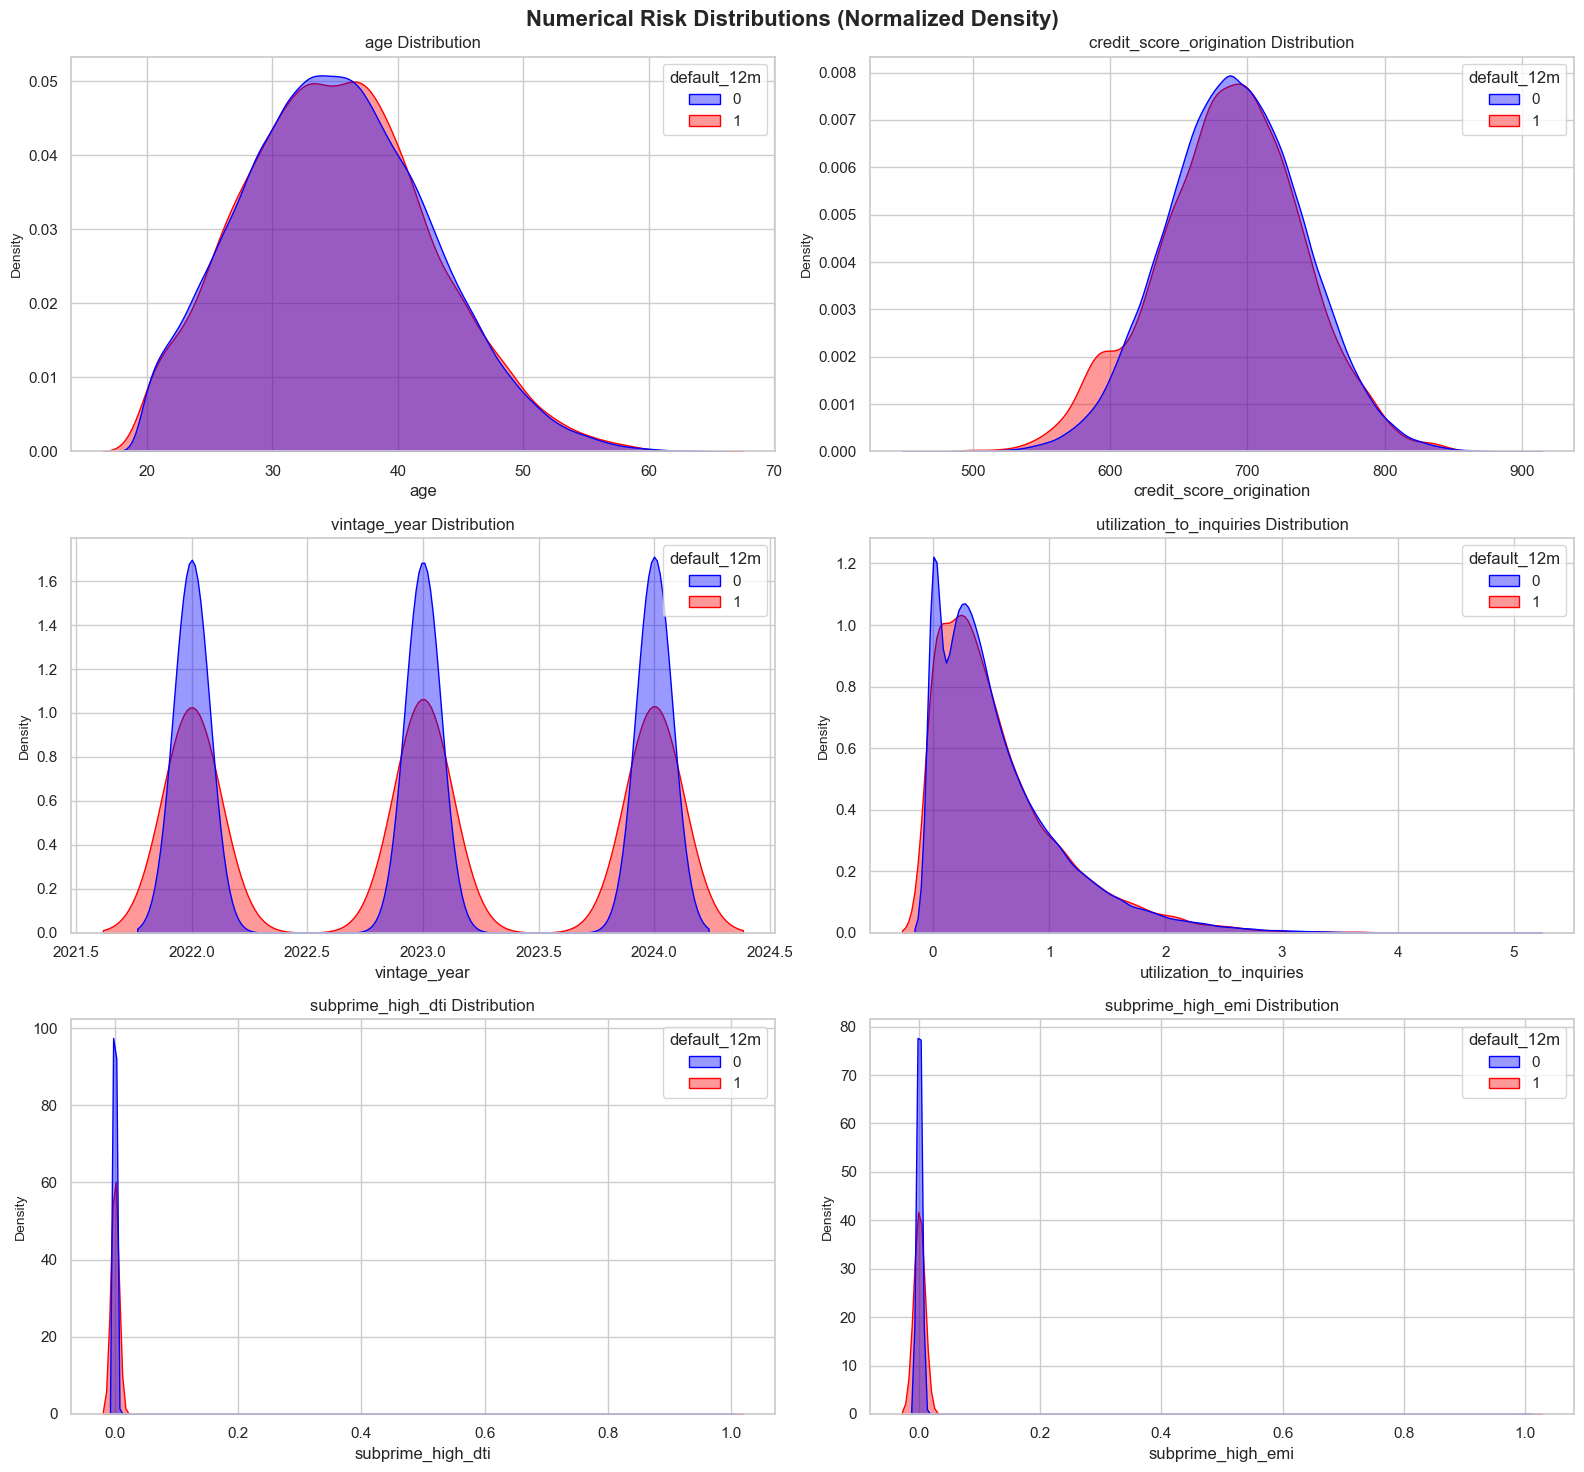

In [ ]:
sns.set_theme(style="whitegrid")

# 1. NUMERICAL FEATURES (Density Plots)
target_col = 'default_12m'
numerical_cols = dataset.select_dtypes(include=['int64', 'float64']).columns.drop(target_col)
categorical_cols = dataset.select_dtypes(include=['object', 'category']).columns

num_to_plot = numerical_cols[:6] # Limit to first 6 to avoid clutter

if len(num_to_plot) > 0:
    num_rows = int(np.ceil(len(num_to_plot) / 2))
    fig, axes = plt.subplots(num_rows, 2, figsize=(16, 5 * num_rows))
    fig.suptitle('Numerical Risk Distributions (Normalized Density)', fontsize=16, fontweight='bold', y=0.98)
    axes = axes.flatten()

    for i, col in enumerate(num_to_plot):
        sns.kdeplot(data=dataset, x=col, hue=target_col, fill=True, common_norm=False,
                    palette={0: 'blue', 1: 'red'}, alpha=0.4, ax=axes[i])
        axes[i].set_title(f'{col} Distribution', fontsize=12)
        axes[i].set_ylabel('Density', fontsize=10)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

# 2. CATEGORICAL FEATURES (Default Rates)
cat_to_plot = categorical_cols[:6]

if len(cat_to_plot) > 0:
    cat_rows = int(np.ceil(len(cat_to_plot) / 2))
    fig, axes = plt.subplots(cat_rows, 2, figsize=(16, 5 * cat_rows))
    fig.suptitle('Categorical Risk: Default Rate per Category', fontsize=16, fontweight='bold', y=0.98)
    axes = axes.flatten()

    for i, col in enumerate(cat_to_plot):
        default_rates = dataset.groupby(col, observed=False)[target_col].mean().sort_values(ascending=False).reset_index()
        sns.barplot(data=default_rates, x=col, y=target_col, ax=axes[i], palette='Reds_r')
        axes[i].set_title(f'Default Rate by {col}', fontsize=12)
        axes[i].set_ylabel('Default Rate', fontsize=10)
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

print("\n=== TOP LINEAR RISK FACTORS ===")
target_corr = dataset[numerical_cols + [target_col]].corr()[target_col].drop(target_col)
print(target_corr.sort_values(ascending=False, key=abs).head(10))

In [ ]:
numeric_transformer = ImbPipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = ImbPipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Define X and y
X = dataset.drop(['default_12m', 'customer_id'], axis=1)
y = dataset['default_12m']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
Rnf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("sm", SMOTE()),
    ('model', RandomForestClassifier(n_jobs=100, class_weight="balanced"))
])

Rnf_pipeline.fit(X_train, y_train)

Rnf_prob = Rnf_pipeline.predict_proba(X_test)[:, 1] # Get probabilities for Class 1
custom_threshold = 0.35
Rnf_pred = (Rnf_prob >= custom_threshold).astype(int)

# Check the new accuracy score
print(f"Random Forest Accuracy: {accuracy_score(y_test, Rnf_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, Rnf_pred))

In [ ]:
Lr = ImbPipeline(
    [
        ('preprocessor', preprocessor),
        ('sm', SMOTE()),
        ('classifier', LogisticRegression(class_weight='balanced'))
    ]
)

Lr.fit(X_train, y_train)
lr_pred = Lr.predict(X_test)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

# Precision-Recall Curve for LR
y_probs = Lr.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.', label='Logistic Regression (Balanced)')
plt.title('Precision-Recall Curve: The Cost of Catching Defaults', fontsize=14, fontweight='bold')
plt.xlabel('Recall (How many defaults did we catch?)', fontsize=12)
plt.ylabel('Precision (When we guess default, how often are we right?)', fontsize=12)
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
tree_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("sm", SMOTE()),
    ('model', DecisionTreeClassifier(random_state=42))
])

tree_pipeline.fit(X_train, y_train)
tree_predict = tree_pipeline.predict(X_test)

print(f"Decision Tree Accuracy: {accuracy_score(y_test, tree_predict) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, tree_predict))

In [ ]:
Ada_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ("sm", SMOTE()),
    ('model', AdaBoostClassifier(random_state=42))
])

Ada_pipeline.fit(X_train, y_train)

ada_prob = Ada_pipeline.predict_proba(X_test)[:, 1] 
custom_threshold = 0.4
Ada_pred = (ada_prob >= custom_threshold).astype(int)

print(f"AdaBoost Accuracy: {accuracy_score(y_test, Ada_pred) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, Ada_pred))